done


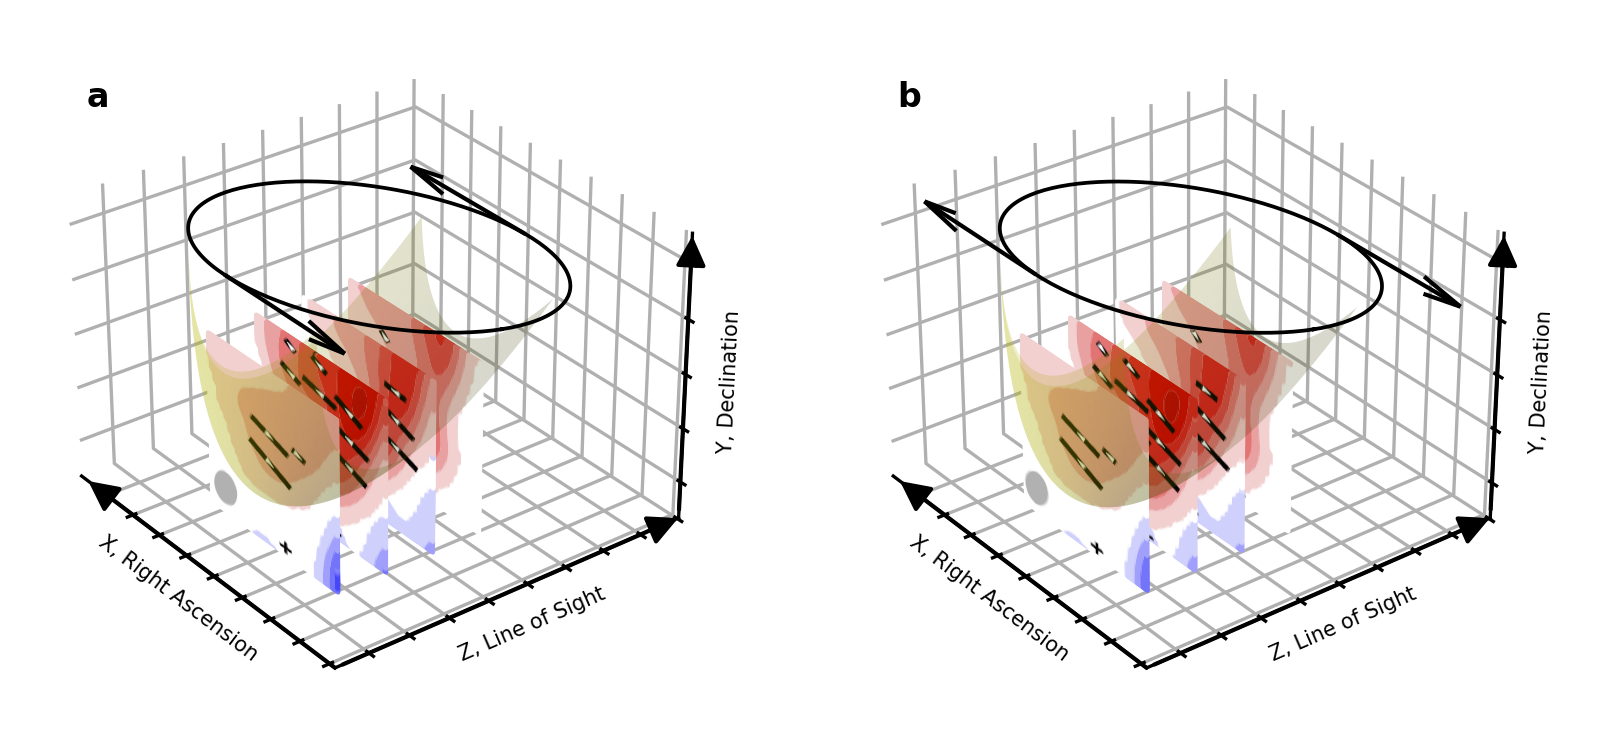

In [30]:
#2025/Feb/26 chingtaochung@gmail.com

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl

font = {'size'   : 5}
mpl.rc('font', **font)

#fig = plt.figure(figsize=(7.2,3.6), dpi=300.) 
fig = plt.figure(dpi=300.) 

C1 = image.imread('B1_120_small.png')
C2 = image.imread('B2_120_small.png')
C3 = image.imread('B3_120_small.png')
C4 = image.imread('B4_120_small.png')
yp, xp, __ = C1.shape
#xp = 173 
#yp = 175
x = np.arange(-xp/2, xp/2, 1) 
y = np.arange(-yp/2, yp/2, 1) 
Y, X = np.meshgrid(y, x)

ax = fig.add_subplot(121, projection='3d')
ax.view_init(elev=30, azim=-37.5)#-36)

###plot sluts####
y_interval = 30 #1600   
y0 = -17
ax.plot_surface(X, 0-y0, Y, facecolors=np.fliplr(C1.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False, zorder=1) #rstride=1, cstride=1
ax.plot_surface(X, 1*y_interval-y0, Y, facecolors=np.fliplr(C2.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False)
ax.plot_surface(X, 2*y_interval-y0, Y, facecolors=np.fliplr(C3.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False)
ax.plot_surface(X, 3*y_interval-y0, Y, facecolors=np.fliplr(C4.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False)

######plot parabolic corn##########
r= 100.
zscale = 0.02

theta = np.linspace(0, 2 * np.pi, 201)
z_c = np.zeros_like(theta)+r**2*zscale
x_c = r*np.cos(theta) 
y_c = r*np.sin(theta) 

Z = (X**2 + Y**2)*zscale
R = np.sqrt(X**2 + Y**2)
angle = -18*np.pi/180 #18 degree inclination of IRAS 4A1 outflow
Y3 = np.cos(angle)*Y-np.sin(angle)*Z
Z3 = np.sin(angle)*Y+np.cos(angle)*Z
y_c2 = np.cos(angle)*y_c-np.sin(angle)*z_c
z_c2 = np.sin(angle)*y_c+np.cos(angle)*z_c

z_shift = 50
x_shift = 10
ax.plot_surface(X-x_shift, Y3+y_interval, Z3-z_shift, color='y',alpha=0.2, zorder=100)
ax.plot(x_c-x_shift,y_c2+y_interval, z_c2-z_shift,color='k',linewidth=0.9, zorder=200)

z_v = r**2*zscale
x_v = 0
y_v = r
z_v2 = r**2*zscale
x_v2 = 0
y_v2 = -r

y_v_2 = np.cos(angle)*y_v-np.sin(angle)*z_v
z_v_2 = np.sin(angle)*y_v+np.cos(angle)*z_v
y_v2_2 = np.cos(angle)*y_v2-np.sin(angle)*z_v2
z_v2_2 = np.sin(angle)*y_v2+np.cos(angle)*z_v2

ax.quiver(x_v-x_shift, y_v_2+y_interval, z_v_2-z_shift, -100, 0, 0, color='k',arrow_length_ratio=0.3,linewidth=1,zorder=200)
ax.quiver(x_v2-x_shift, y_v2_2+y_interval, z_v2_2-z_shift, 100, 0, 0, color='k',arrow_length_ratio=0.3,linewidth=1,zorder=200)

################
ax.set_xlabel("X, Right Ascension", labelpad=-15)
ax.set_ylabel("Z, Line of Sight", labelpad=-15)
ax.set_zlabel("Y, Declination", labelpad=-15)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
ax.axes.zaxis.set_ticklabels([])
ax.text2D(0.1,0.9, r'a',horizontalalignment='center',verticalalignment='center',transform=ax.transAxes, fontsize=8, weight='bold')

#########
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.proj3d import proj_transform
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

class Arrow3D(FancyArrowPatch):

    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj3d.proj_transform(
            (x1, x2), (y1, y2), (z1, z2), self.axes.M
        )
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj3d.proj_transform(
            (x1, x2), (y1, y2), (z1, z2), self.axes.M
        )
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        # Return z-order value (important!)
        return np.min(zs)
        
xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
zlim = plt.gca().get_zlim()
#print(xlim,ylim,zlim)
#(np.float64(-124.58333333333333), np.float64(104.58333333333333))
#(np.float64(-20.695627246241905), np.float64(201.01810627397305))
#(np.float64(-84.21068755617762), np.float64(176.32369025270305))
ax.arrow3D(xlim[0], ylim[0], zlim[0], xlim[1]-xlim[0]+5, 0, 0, mutation_scale=15, arrowstyle='<|-',fc='k') # x axis
ax.arrow3D(xlim[1], ylim[0], zlim[0], 0, ylim[1]-ylim[0]+5, 0, mutation_scale=15, arrowstyle='-|>',fc='k') # x axis
ax.arrow3D(xlim[1], ylim[1], zlim[0], 0, 0, zlim[1]-zlim[0]+5, mutation_scale=15, arrowstyle='-|>',fc='k') # x axis

################
C1 = image.imread('B1_2_120_small.png')
C2 = image.imread('B2_2_120_small.png')
C3 = image.imread('B3_2_120_small.png')
C4 = image.imread('B4_2_120_small.png')
yp, xp, __ = C1.shape
x = np.arange(-xp/2, xp/2, 1) 
y = np.arange(-yp/2, yp/2, 1) 
Y, X = np.meshgrid(y, x)

ax2 = fig.add_subplot(122, projection='3d')
ax2.view_init(elev=30, azim=-37.5)#-36)

###plot sluts####
ax2.plot_surface(X, 0-y0, Y, facecolors=np.fliplr(C1.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False, zorder=1) #rstride=1, cstride=1
ax2.plot_surface(X, 1*y_interval-y0, Y, facecolors=np.fliplr(C2.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False)
ax2.plot_surface(X, 2*y_interval-y0, Y, facecolors=np.fliplr(C3.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False)
ax2.plot_surface(X, 3*y_interval-y0, Y, facecolors=np.fliplr(C4.transpose((1,0,2))),
                rstride=1, cstride=1, antialiased=True, shade=False)

######plot parabolic corn##########
r= 100.
zscale = 0.02

theta = np.linspace(0, 2 * np.pi, 201)
z_c = np.zeros_like(theta)+r**2*zscale
x_c = r*np.cos(theta) 
y_c = r*np.sin(theta) 

Z = (X**2 + Y**2)*zscale
R = np.sqrt(X**2 + Y**2)
angle = -18*np.pi/180 #18 degree inclination of IRAS 4A1 outflow
Y3 = np.cos(angle)*Y-np.sin(angle)*Z
Z3 = np.sin(angle)*Y+np.cos(angle)*Z
y_c2 = np.cos(angle)*y_c-np.sin(angle)*z_c
z_c2 = np.sin(angle)*y_c+np.cos(angle)*z_c

ax2.plot_surface(X-x_shift, Y3+y_interval, Z3-z_shift, color='y',alpha=0.2, zorder=100)
ax2.plot(x_c-x_shift,y_c2+y_interval, z_c2-z_shift,color='k',linewidth=0.9, zorder=200)

z_v = r**2*zscale
x_v = 0
y_v = r
z_v2 = r**2*zscale
x_v2 = 0
y_v2 = -r

y_v_2 = np.cos(angle)*y_v-np.sin(angle)*z_v
z_v_2 = np.sin(angle)*y_v+np.cos(angle)*z_v
y_v2_2 = np.cos(angle)*y_v2-np.sin(angle)*z_v2
z_v2_2 = np.sin(angle)*y_v2+np.cos(angle)*z_v2

ax2.quiver(x_v-x_shift, y_v_2+y_interval, z_v_2-z_shift, 100, 0, 0, color='k',arrow_length_ratio=0.3,linewidth=1,zorder=200)
ax2.quiver(x_v2-x_shift, y_v2_2+y_interval, z_v2_2-z_shift, -100, 0, 0, color='k',arrow_length_ratio=0.3,linewidth=1,zorder=200)

################
ax2.set_xlabel("X, Right Ascension", labelpad=-15)
ax2.set_ylabel("Z, Line of Sight", labelpad=-15)
ax2.set_zlabel("Y, Declination", labelpad=-15)
ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.axes.xaxis.set_ticklabels([])
ax2.axes.yaxis.set_ticklabels([])
ax2.axes.zaxis.set_ticklabels([])
ax2.text2D(0.1,0.9, r'b',horizontalalignment='center',verticalalignment='center',transform=ax2.transAxes, fontsize=8, weight='bold')

xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
zlim = plt.gca().get_zlim()
#print(xlim,ylim,zlim)
ax2.arrow3D(xlim[0], ylim[0], zlim[0], xlim[1]-xlim[0]+5, 0, 0, mutation_scale=15, arrowstyle='<|-',fc='k') # x axis
ax2.arrow3D(xlim[1], ylim[0], zlim[0], 0, ylim[1]-ylim[0]+5, 0, mutation_scale=15, arrowstyle='-|>',fc='k') # x axis
ax2.arrow3D(xlim[1], ylim[1], zlim[0], 0, 0, zlim[1]-zlim[0]+5, mutation_scale=15, arrowstyle='-|>',fc='k') # x axis

plt.savefig('3d_B_NC.pdf', transparent=True,dpi=300.)
print('done')